In [2]:
%load_ext autoreload
%autoreload

开始进行实验
实验 1/3: p=0.1, size=400x400
实验 2/3: p=0.36, size=400x400
实验 3/3: p=0.9, size=400x400
所有 3 个实验完成。
p=0.1, 计算方式: {'device': 'CPU', 'parallelism': 'single-thread'}
p=0.36, 计算方式: {'device': 'CPU', 'parallelism': 'multi-thread'}
p=0.9, 计算方式: {'device': 'GPU', 'parallelism': 'single-thread'}
元数据已保存至 experiment/test\test_meta.json
最终网格已保存至 experiment/test\test_final_grids.npz
   cfg_p device    parallelism  initial  final
0   0.10    CPU  single-thread    16121   7239
1   0.36    CPU   multi-thread    57735  11504
2   0.90    GPU  single-thread   143917      0

显示第一个实验的最终网格：


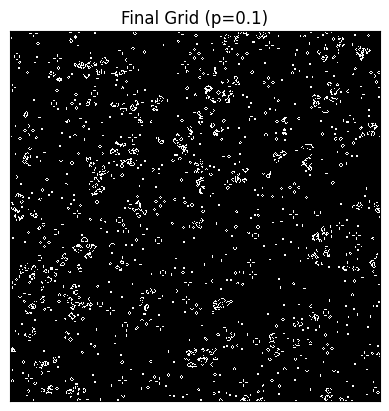


显示第一个实验的细胞数量变化：


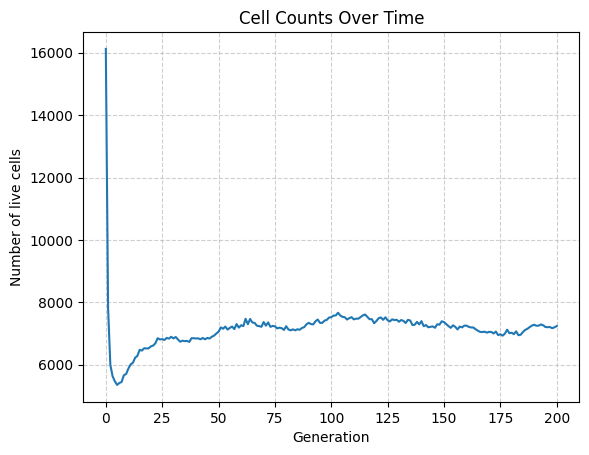


显示所有实验的最终网格对比：


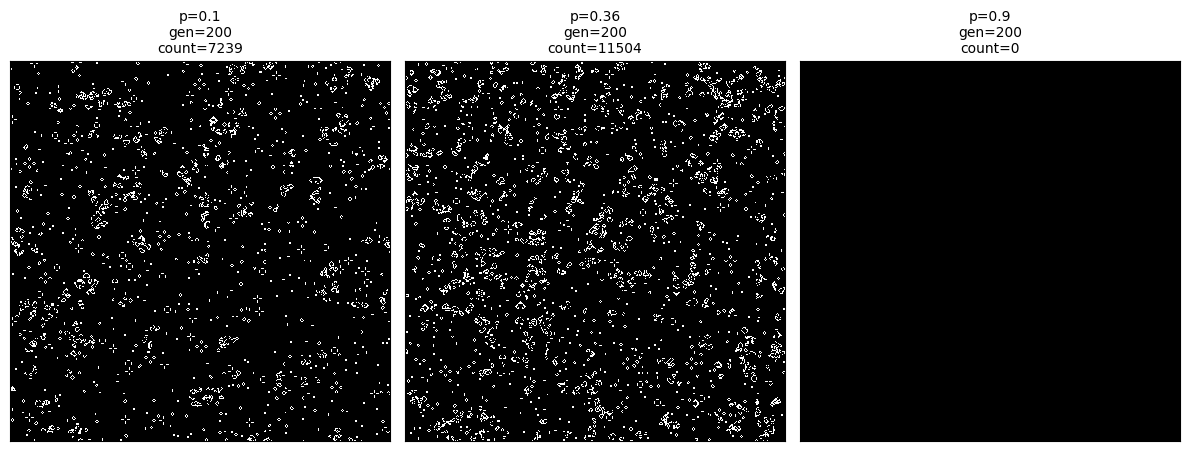

In [9]:
from lifegame import *

# 测试
exp_test_config = [
    {'p': 0.10, 'rows': 400, 'cols': 400, 'max_steps': 200, 'seed': 40, 'computation_info': {'device': 'CPU', 'parallelism': 'single-thread'}},
    {'p': 0.36, 'rows': 400, 'cols': 400, 'max_steps': 200, 'seed': 146, 'computation_info': {'device': 'CPU', 'parallelism': 'multi-thread'}},
    {'p': 0.90, 'rows': 400, 'cols': 400, 'max_steps': 200, 'seed': 341, 'computation_info': {'device': 'GPU', 'parallelism': 'single-thread'}}
]
exp_test = Experiment(configs = exp_test_config, save_dir = 'experiment/test')

print("开始进行实验")
# 3. 运行所有实验
results = exp_test.run_all()

for r in results:
        print(f"p={r['config']['p']}, 计算方式: {r['computation_info']}")

# 5. 保存结果
exp_test.save_results('test')

# 6. 转换为 DataFrame 查看
df = exp_test.to_dataframe()
if df is not None:
    print(df[['cfg_p', 'device', 'parallelism', 'initial', 'final']])

print("\n显示第一个实验的最终网格：")
Visualizer.plot_grid(results[0]['final_grid'], title=f"Final Grid (p={results[0]['config']['p']})")
print("\n显示第一个实验的细胞数量变化：")
Visualizer.plot_cell_counts(results[0]['cell_counts'], title="Cell Counts Over Time")
print("\n显示所有实验的最终网格对比：")
Visualizer.plot_final_grids(results, max_cols=3)
ani = Visualizer.animate_history(results[0]['history'], interval=100)
ani.save('experiment/test/game_of_life.gif', writer='pillow', fps=10)

In [ ]:
# 正式实验
